# Notebook 03 — Développement des modèles (Rebuild 2026)

| | |
|---|---|
| **Projet** | Application Intelligente de Scoring Client |
| **Entreprise** | Orus Services — filiale Salafin, Bank of Africa |
| **Auteure** | Fatima Zahra Ait Lamine |
| **Année** | PFE 2025–2026 (rebuild du pipeline ML) |

---

## Objectif et cahier des charges de la phase 3

Comparer **Logistic Regression, Random Forest et XGBoost** en validation croisée stratifiée
5-fold **sur le train uniquement** (le test de 20 % reste intouché jusqu'à la phase 4), avec :

1. **Batterie de métriques complète** : ROC-AUC, PR-AUC, Brier, Log Loss, MCC, Précision,
   Rappel, F1, statistique KS, Precision@Top10 %, Recall@Top10 %, courbes de calibration.
2. **Comparaison de 3 stratégies de calibration** : aucune / Platt (sigmoïde) / isotonique.
3. **Seuil de décision optimisé sur les folds de validation** (pas de 0.5 par défaut) —
   ce seuil sera réutilisé par l'application.
4. **Early stopping** pour XGBoost, sans fuite (voir méthodologie).
5. **Recherche d'hyperparamètres raisonnable et justifiée** — robustesse > gain marginal.
6. **Pas de SHAP ici** : l'explicabilité (phase 5) ne concernera que le modèle final retenu.

## Méthodologie anti-fuite

- **Prédictions out-of-fold (OOF)** : chaque ligne du train reçoit une probabilité prédite
  par un modèle qui ne l'a jamais vue (5-fold stratifié, seed 42). Toutes les métriques
  sont calculées sur ces prédictions honnêtes.
- **Winsorisation/imputation ré-estimées dans chaque fold** (le `FittedPreprocessor` de la
  phase 2 est refitté sur les 4/5 d'entraînement de chaque fold).
- **Early stopping sans fuite** : à l'intérieur de chaque fold, 10 % du fold-train sert de
  jeu d'arrêt — le fold de validation n'influence jamais l'entraînement.
- **Calibration évaluée par CV sur les prédictions OOF** : équivalent exact de
  `CalibratedClassifierCV(ensemble=False)` — le calibreur n'est jamais évalué sur les
  points qui ont servi à l'ajuster.
- **Seuil optimisé sur les probabilités OOF calibrées** — jamais sur le test.

## 1. Imports, données et reconstruction du split

In [1]:
import sys, os, pickle, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('../src'))
from preprocessing import (clean_gmsc, drop_training_rows, FittedPreprocessor, Log1pIncome,
                           FEATURE_COLS, TARGET, MONOTONE_CONSTRAINTS)

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.isotonic import IsotonicRegression
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             log_loss, matthews_corrcoef, precision_score, recall_score,
                             f1_score, roc_curve, precision_recall_curve)
from scipy.special import logit, expit

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11, 'axes.titleweight': 'bold'})
os.makedirs('figures', exist_ok=True)
SEED = 42
MODELS_PATH = '../models/'

# Reconstruction déterministe du split de la phase 2 (mêmes opérations, même seed)
raw = pd.read_csv('../data/GiveMeSomeCredit-training.csv', index_col=0)
df = drop_training_rows(raw)
train_df, _test_df = train_test_split(df, test_size=0.20, random_state=SEED, stratify=df[TARGET])
train_c = clean_gmsc(train_df)
X = train_c[FEATURE_COLS].reset_index(drop=True)
y = train_c[TARGET].reset_index(drop=True)

# Garde-fou : le split reconstruit doit être identique à celui sauvegardé en phase 2
y_saved = pd.read_csv('../data/processed/y_train.csv').squeeze()
assert len(y) == len(y_saved) == 119512 and (y.values == y_saved.values).all(), "split non identique à la phase 2 !"
del _test_df  # le test n'est PAS chargé — phase 4 uniquement
print(f"Train : {len(X):,} lignes × {X.shape[1]} features — défaut {y.mean()*100:.3f}%")
print("Split identique à la phase 2 : OK — le test set n'est pas chargé dans ce notebook.")

Train : 119,512 lignes × 12 features — défaut 6.700%
Split identique à la phase 2 : OK — le test set n'est pas chargé dans ce notebook.


## 2. Métriques et outils communs

- **KS** : max|TPR − FPR| — écart maximal entre les distributions cumulées des scores
  des défauts et des non-défauts (standard du scoring bancaire).
- **Precision@Top10 % / Recall@Top10 %** : qualité du ciblage si l'on ne peut examiner
  que les 10 % de dossiers les plus risqués (usage opérationnel du score).
- **ECE** (Expected Calibration Error) : moyenne pondérée des écarts |proba prédite −
  fréquence observée| sur 10 bandes de quantiles — quantifie la courbe de calibration.

In [2]:
def ks_stat(y_true, p):
    fpr, tpr, _ = roc_curve(y_true, p)
    return float(np.max(tpr - fpr))

def prec_recall_at_top(y_true, p, frac=0.10):
    n = max(int(len(p) * frac), 1)
    idx = np.argsort(p)[::-1][:n]
    caught = y_true.values[idx].sum() if hasattr(y_true, 'values') else y_true[idx].sum()
    return float(caught / n), float(caught / y_true.sum())

def ece_score(y_true, p, bins=10):
    b = pd.qcut(pd.Series(p), bins, duplicates='drop')
    g = pd.DataFrame({'p': p, 'y': np.asarray(y_true)}).groupby(b, observed=True)
    agg = g.agg(pm=('p', 'mean'), ym=('y', 'mean'), n=('y', 'size'))
    return float((np.abs(agg.pm - agg.ym) * agg.n).sum() / agg.n.sum())

def fit_calibrator(p, y_true, method):
    if method == 'platt':
        z = logit(np.clip(p, 1e-6, 1 - 1e-6)).reshape(-1, 1)
        m = LogisticRegression(C=1e10, solver='lbfgs', max_iter=1000)
        m.fit(z, y_true)
        return {'method': 'platt', 'model': m}
    if method == 'isotonic':
        m = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds='clip')
        m.fit(p, y_true)
        return {'method': 'isotonic', 'model': m}
    return {'method': 'none', 'model': None}

def apply_calibrator(cal, p):
    if cal['method'] == 'platt':
        return cal['model'].predict_proba(logit(np.clip(p, 1e-6, 1 - 1e-6)).reshape(-1, 1))[:, 1]
    if cal['method'] == 'isotonic':
        return cal['model'].predict(p)
    return p

def calib_cv(p_raw, y_true, method, n_splits=5, seed=SEED):
    """CV 5-fold SUR les prédictions OOF : le calibreur est ajusté sur 4/5 des points
    et évalué sur le 1/5 restant — jamais sur ses propres points d'ajustement."""
    if method == 'none':
        return p_raw.copy()
    out = np.zeros_like(p_raw)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for tr, va in skf.split(p_raw.reshape(-1, 1), y_true):
        cal = fit_calibrator(p_raw[tr], y_true.iloc[tr], method)
        out[va] = apply_calibrator(cal, p_raw[va])
    return out

def best_threshold_f1(y_true, p):
    prec, rec, thr = precision_recall_curve(y_true, p)
    f1 = 2 * prec * rec / np.clip(prec + rec, 1e-12, None)
    i = int(np.nanargmax(f1[:-1]))
    return float(thr[i]), float(f1[i]), float(prec[i]), float(rec[i])

def best_threshold_mcc(y_true, p):
    best = (0.5, -1)
    for t in np.quantile(p, np.linspace(0.5, 0.995, 100)):
        m = matthews_corrcoef(y_true, (p >= t).astype(int))
        if m > best[1]:
            best = (float(t), float(m))
    return best

print('Outils prêts.')

Outils prêts.


## 3. Harnais de validation croisée (prédictions out-of-fold)

Deux chemins :
- **LR / RF** : `Pipeline sklearn` (préprocesseur avec imputation → [log/scaler] → modèle),
  refitté intégralement dans chaque fold.
- **XGBoost** : préprocesseur sans imputation (NaN natifs) + early stopping sur 10 %
  du fold-train (`n_estimators=2000` plafond, arrêt à 50 rounds sans amélioration).

In [3]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
FOLDS = list(skf.split(X, y))

def cv_oof_pipeline(make_pipe):
    oof = np.zeros(len(y)); fold_auc = []
    for tr, va in FOLDS:
        pipe = make_pipe()
        pipe.fit(X.iloc[tr], y.iloc[tr])
        p = pipe.predict_proba(X.iloc[va])[:, 1]
        oof[va] = p
        fold_auc.append(roc_auc_score(y.iloc[va], p))
    return oof, np.array(fold_auc)

def cv_oof_xgb(params):
    oof = np.zeros(len(y)); fold_auc = []; best_iters = []
    for tr, va in FOLDS:
        X_tr, y_tr = X.iloc[tr], y.iloc[tr]
        # 10% du fold-train pour l'arrêt — le fold de validation reste hors de l'entraînement
        X_fit, X_es, y_fit, y_es = train_test_split(X_tr, y_tr, test_size=0.10,
                                                    random_state=SEED, stratify=y_tr)
        prep = FittedPreprocessor(impute=False).fit(X_fit)
        clf = XGBClassifier(**params)
        clf.fit(prep.transform(X_fit), y_fit,
                eval_set=[(prep.transform(X_es), y_es)], verbose=False)
        p = clf.predict_proba(prep.transform(X.iloc[va]))[:, 1]
        oof[va] = p
        fold_auc.append(roc_auc_score(y.iloc[va], p))
        best_iters.append(int(clf.best_iteration))
    return oof, np.array(fold_auc), best_iters

MONO = tuple(MONOTONE_CONSTRAINTS[c] for c in FEATURE_COLS)
SPW = float((y == 0).sum() / (y == 1).sum())
print(f"scale_pos_weight = {SPW:.2f} | contraintes monotones : {MONO}")

scale_pos_weight = 13.93 | contraintes monotones : (1, -1, 1, 0, -1, 0, 1, 0, 1, 1, 1, -1)


## 4. Régression Logistique — grille : C ∈ {0.01, 0.1, 1, 10}

Un seul hyperparamètre pertinent (force de régularisation L2), balayé sur 4 ordres de
grandeur : suffisant pour situer l'optimum, tout raffinement supplémentaire serait du
bruit statistique. `class_weight='balanced'` = correction unique du déséquilibre.
Pipeline : imputation médiane → log1p(revenu) → standardisation → LR.

In [4]:
res_lr = {}
t0 = time.time()
for Cval in [0.01, 0.1, 1.0, 10.0]:
    make = lambda Cv=Cval: Pipeline([
        ('prep', FittedPreprocessor(impute=True)),
        ('log', Log1pIncome()),
        ('scale', StandardScaler()),
        ('clf', LogisticRegression(C=Cv, class_weight='balanced', max_iter=2000, random_state=SEED)),
    ])
    oof, fauc = cv_oof_pipeline(make)
    res_lr[Cval] = {'oof': oof, 'fold_auc': fauc}
    print(f"C={Cval:<6} AUC folds = {fauc.mean():.4f} ± {fauc.std():.4f}")
best_C = max(res_lr, key=lambda k: res_lr[k]['fold_auc'].mean())
oof_lr, fauc_lr = res_lr[best_C]['oof'], res_lr[best_C]['fold_auc']
print(f"→ retenu : C={best_C}  ({time.time()-t0:.0f}s)")

C=0.01   AUC folds = 0.8562 ± 0.0021


C=0.1    AUC folds = 0.8562 ± 0.0021


C=1.0    AUC folds = 0.8562 ± 0.0021


C=10.0   AUC folds = 0.8562 ± 0.0021
→ retenu : C=1.0  (7s)


## 5. Random Forest — grille : max_depth × min_samples_leaf (2×2)

`n_estimators=300` fixé (au-delà, la variance de l'AUC décroît sans gain — les forêts ne
sur-apprennent pas avec plus d'arbres, on paie juste en temps). La grille couvre le vrai
levier de régularisation : profondeur (interactions) × taille de feuille (lissage).
`class_weight='balanced_subsample'` = correction unique du déséquilibre.
NB : Random Forest ne supporte **pas** les contraintes monotones — handicap d'explicabilité
consigné dans le tableau final.

In [5]:
res_rf = {}
t0 = time.time()
for depth in [12, None]:
    for leaf in [5, 20]:
        make = lambda d=depth, l=leaf: Pipeline([
            ('prep', FittedPreprocessor(impute=True)),
            ('clf', RandomForestClassifier(n_estimators=300, max_depth=d, min_samples_leaf=l,
                                           class_weight='balanced_subsample',
                                           random_state=SEED, n_jobs=-1)),
        ])
        oof, fauc = cv_oof_pipeline(make)
        res_rf[(depth, leaf)] = {'oof': oof, 'fold_auc': fauc}
        print(f"max_depth={str(depth):<5} min_samples_leaf={leaf:<3} AUC folds = {fauc.mean():.4f} ± {fauc.std():.4f}")
best_rf_cfg = max(res_rf, key=lambda k: res_rf[k]['fold_auc'].mean())
oof_rf, fauc_rf = res_rf[best_rf_cfg]['oof'], res_rf[best_rf_cfg]['fold_auc']
print(f"→ retenu : max_depth={best_rf_cfg[0]}, min_samples_leaf={best_rf_cfg[1]}  ({time.time()-t0:.0f}s)")

max_depth=12    min_samples_leaf=5   AUC folds = 0.8583 ± 0.0031


max_depth=12    min_samples_leaf=20  AUC folds = 0.8628 ± 0.0028


max_depth=None  min_samples_leaf=5   AUC folds = 0.8550 ± 0.0032


max_depth=None  min_samples_leaf=20  AUC folds = 0.8611 ± 0.0033
→ retenu : max_depth=12, min_samples_leaf=20  (812s)


## 6. XGBoost — grille : max_depth × min_child_weight (2×2), early stopping

- `learning_rate=0.05` fixé : avec early stopping, le nombre d'arbres s'ajuste
  automatiquement — balayer le learning rate ET le nombre d'arbres serait redondant.
- `max_depth ∈ {4, 6}` : ordre d'interaction faible, standard sur données tabulaires de crédit.
- `min_child_weight ∈ {1, 10}` : régularisation des feuilles rares.
- `subsample=0.8, colsample_bytree=0.8, reg_lambda=1` : valeurs par défaut robustes.
- `scale_pos_weight ≈ 13.9` : correction unique du déséquilibre.
- **Contraintes monotones vérifiées en phase 2** appliquées à chaque fit.
- **Early stopping** : plafond 2 000 arbres, arrêt après 50 rounds sans gain de logloss
  sur les 10 % d'arrêt internes au fold-train.

In [6]:
res_xgb = {}
t0 = time.time()
base = dict(n_estimators=2000, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
            reg_lambda=1.0, monotone_constraints=MONO, scale_pos_weight=SPW,
            tree_method='hist', early_stopping_rounds=50, eval_metric='logloss',
            random_state=SEED, n_jobs=-1, verbosity=0)
for depth in [4, 6]:
    for mcw in [1, 10]:
        params = dict(base, max_depth=depth, min_child_weight=mcw)
        oof, fauc, iters = cv_oof_xgb(params)
        res_xgb[(depth, mcw)] = {'oof': oof, 'fold_auc': fauc, 'best_iters': iters}
        print(f"max_depth={depth} min_child_weight={mcw:<3} AUC folds = {fauc.mean():.4f} ± {fauc.std():.4f}"
              f"  arbres (ES) = {iters}")
best_xgb_cfg = max(res_xgb, key=lambda k: res_xgb[k]['fold_auc'].mean())
oof_xgb, fauc_xgb = res_xgb[best_xgb_cfg]['oof'], res_xgb[best_xgb_cfg]['fold_auc']
best_iters_xgb = res_xgb[best_xgb_cfg]['best_iters']
print(f"→ retenu : max_depth={best_xgb_cfg[0]}, min_child_weight={best_xgb_cfg[1]}  ({time.time()-t0:.0f}s)")

max_depth=4 min_child_weight=1   AUC folds = 0.8550 ± 0.0033  arbres (ES) = [1257, 530, 1235, 1333, 753]


max_depth=4 min_child_weight=10  AUC folds = 0.8579 ± 0.0026  arbres (ES) = [858, 354, 1235, 887, 754]


max_depth=6 min_child_weight=1   AUC folds = 0.8478 ± 0.0123  arbres (ES) = [1257, 1156, 82, 1429, 83]


max_depth=6 min_child_weight=10  AUC folds = 0.8512 ± 0.0095  arbres (ES) = [1244, 1153, 82, 1302, 83]
→ retenu : max_depth=4, min_child_weight=10  (440s)


## 7. Comparaison des modèles bruts (probabilités OOF non calibrées)

Les métriques de **discrimination** (AUC, PR-AUC, KS, Top10 %) ne dépendent pas de la
calibration ; Brier et Log Loss bruts montrent au contraire l'effet de la pondération de
classes sur l'échelle des probabilités — c'est exactement ce que la calibration (§8) corrige.

In [7]:
OOF = {'Logistic Regression': oof_lr, 'Random Forest': oof_rf, 'XGBoost': oof_xgb}
FAUC = {'Logistic Regression': fauc_lr, 'Random Forest': fauc_rf, 'XGBoost': fauc_xgb}

rows = []
for name, p in OOF.items():
    p10, r10 = prec_recall_at_top(y, p, 0.10)
    rows.append({
        'modèle': name,
        'ROC-AUC (folds)': f"{FAUC[name].mean():.4f} ± {FAUC[name].std():.4f}",
        'PR-AUC': round(average_precision_score(y, p), 4),
        'KS': round(ks_stat(y, p), 4),
        'P@Top10%': round(p10, 4),
        'R@Top10%': round(r10, 4),
        'Brier (brut)': round(brier_score_loss(y, p), 4),
        'LogLoss (brut)': round(log_loss(y, p), 4),
    })
df_raw = pd.DataFrame(rows)
print(df_raw.to_string(index=False))
print(f"\nRappel — taux de base : {y.mean()*100:.2f}% ; Brier naïf (prédire 0.067 partout) = {brier_score_loss(y, np.full(len(y), y.mean())):.4f}")

             modèle ROC-AUC (folds)  PR-AUC     KS  P@Top10%  R@Top10%  Brier (brut)  LogLoss (brut)
Logistic Regression 0.8562 ± 0.0021  0.3815 0.5507    0.3567    0.5324        0.1450          0.4813
      Random Forest 0.8628 ± 0.0028  0.3895 0.5666    0.3627    0.5414        0.1248          0.4006
            XGBoost 0.8579 ± 0.0026  0.3862 0.5603    0.3611    0.5390        0.1385          0.4404

Rappel — taux de base : 6.70% ; Brier naïf (prédire 0.067 partout) = 0.0625


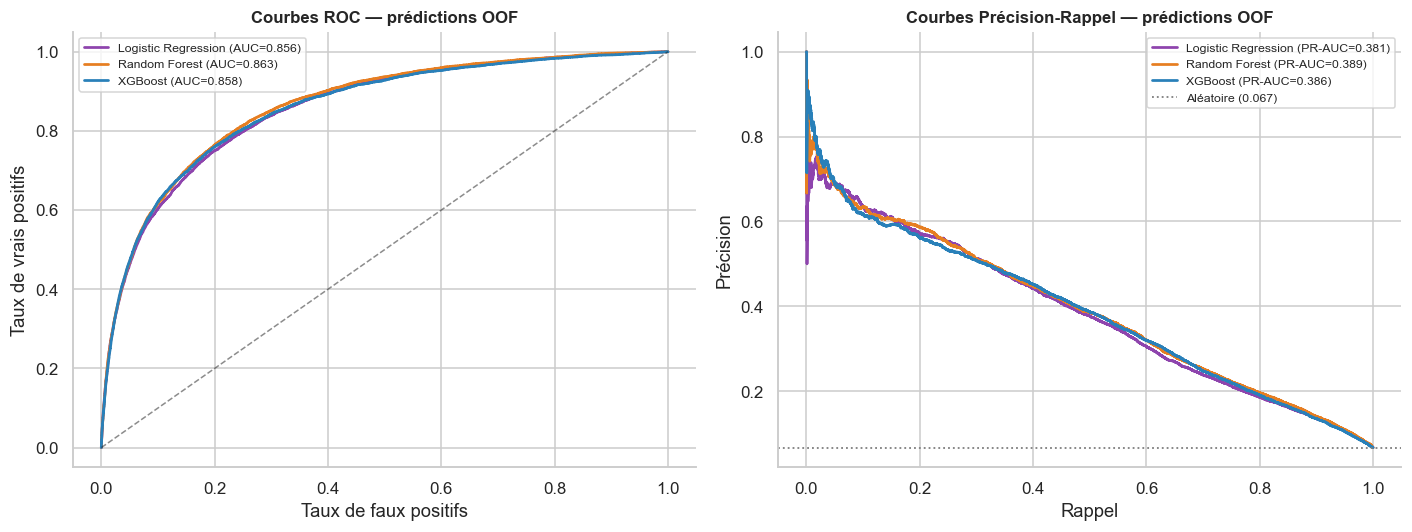

In [8]:
# Courbes ROC et Précision-Rappel (OOF)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {'Logistic Regression': '#8e44ad', 'Random Forest': '#e67e22', 'XGBoost': '#2980b9'}
for name, p in OOF.items():
    fpr, tpr, _ = roc_curve(y, p)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y, p):.3f})", color=colors[name], lw=1.8)
    prec, rec, _ = precision_recall_curve(y, p)
    axes[1].plot(rec, prec, label=f"{name} (PR-AUC={average_precision_score(y, p):.3f})", color=colors[name], lw=1.8)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=.5)
axes[0].set(title='Courbes ROC — prédictions OOF', xlabel='Taux de faux positifs', ylabel='Taux de vrais positifs')
axes[1].axhline(y.mean(), color='gray', ls=':', lw=1.2, label=f'Aléatoire ({y.mean():.3f})')
axes[1].set(title='Courbes Précision-Rappel — prédictions OOF', xlabel='Rappel', ylabel='Précision')
for ax in axes: ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/fig_R03_roc_pr_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Comparaison des calibrations : aucune / Platt / isotonique

La pondération de classes (unique correction du déséquilibre) gonfle mécaniquement les
probabilités — utile pour l'apprentissage, faux pour la lecture « probabilité de défaut ».
On compare les trois options **par CV 5-fold sur les prédictions OOF** : le calibreur est
toujours évalué sur des points qu'il n'a pas vus. Critères : Brier, Log Loss, ECE.

In [9]:
cal_rows, p_cal_best = [], {}
for name, p in OOF.items():
    scores = {}
    for method in ['none', 'platt', 'isotonic']:
        pc = calib_cv(p, y, method)
        scores[method] = {'Brier': brier_score_loss(y, pc), 'LogLoss': log_loss(y, np.clip(pc, 1e-6, 1-1e-6)),
                          'ECE': ece_score(y, pc)}
        cal_rows.append({'modèle': name, 'calibration': method,
                         **{k: round(v, 4) for k, v in scores[method].items()}})
    best_m = min(scores, key=lambda m: scores[m]['Brier'])
    p_cal_best[name] = {'method': best_m, 'p': calib_cv(p, y, best_m)}
    print(f"{name:<22} → meilleure calibration : {best_m}")
df_cal = pd.DataFrame(cal_rows)
print()
print(df_cal.pivot(index='modèle', columns='calibration', values='Brier').round(4).to_string())
print('\n(tableau complet Brier/LogLoss/ECE sauvegardé avec les artefacts)')

Logistic Regression    → meilleure calibration : isotonic


Random Forest          → meilleure calibration : platt


XGBoost                → meilleure calibration : isotonic

calibration          isotonic    none   platt
modèle                                       
Logistic Regression    0.0500  0.1450  0.0511
Random Forest          0.0496  0.1248  0.0496
XGBoost                0.0498  0.1385  0.0499

(tableau complet Brier/LogLoss/ECE sauvegardé avec les artefacts)


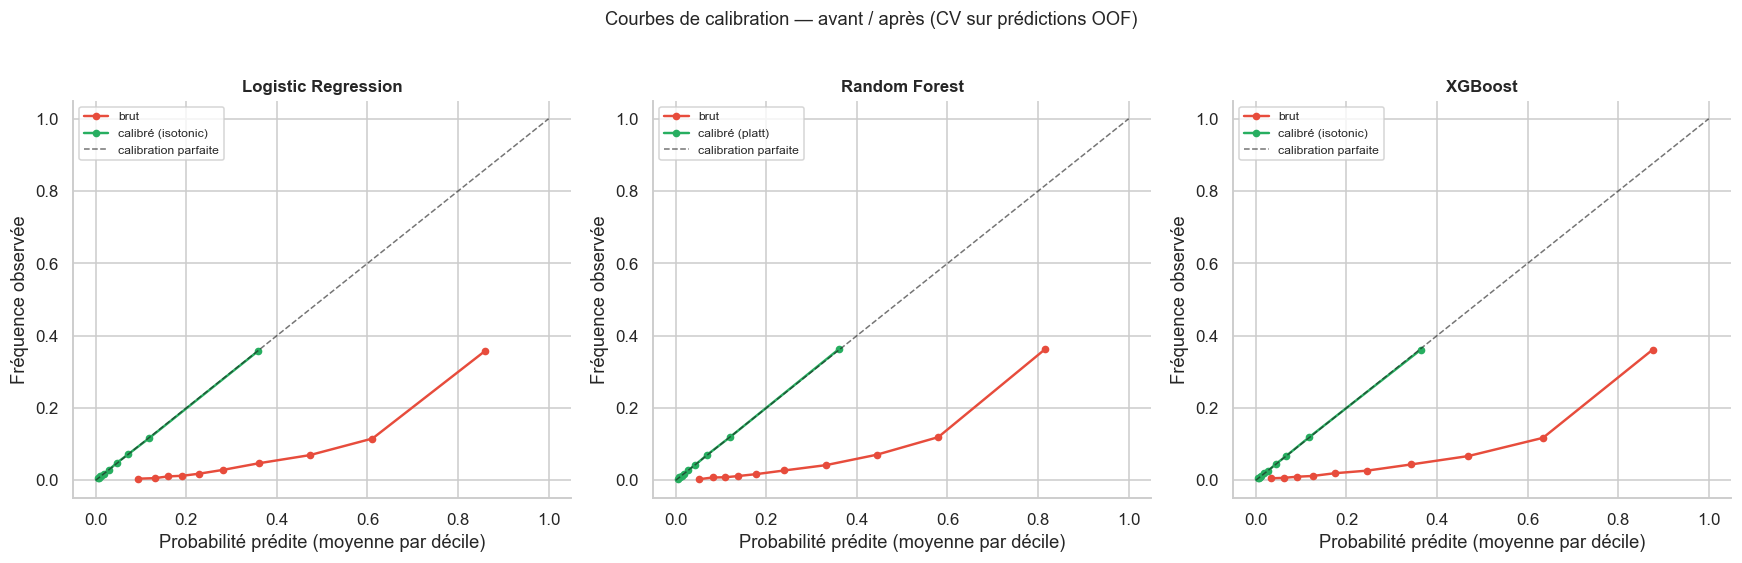

In [10]:
# Courbes de calibration avant / après (10 bandes de quantiles)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, p_raw) in zip(axes, OOF.items()):
    for p_plot, lab, col in [(p_raw, 'brut', '#e74c3c'),
                             (p_cal_best[name]['p'], f"calibré ({p_cal_best[name]['method']})", '#27ae60')]:
        b = pd.qcut(pd.Series(p_plot), 10, duplicates='drop')
        g = pd.DataFrame({'p': p_plot, 'y': y.values}).groupby(b, observed=True).mean()
        ax.plot(g.p, g.y, 'o-', color=col, label=lab, lw=1.6, ms=4)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=.6, label='calibration parfaite')
    ax.set(title=name, xlabel='Probabilité prédite (moyenne par décile)', ylabel='Fréquence observée')
    ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)
plt.suptitle('Courbes de calibration — avant / après (CV sur prédictions OOF)', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('figures/fig_R03_calibration_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Optimisation du seuil de décision (sur probabilités OOF calibrées)

Sans matrice de coûts formelle fournie par Orus, on maximise le **F1** (équilibre
précision/rappel sur la classe défaut) ; le seuil optimal MCC est donné en contrôle.
Le seuil retenu sera sauvegardé et réutilisé par l'application (plus de 0.5 implicite).

In [11]:
thr_rows, thr_choice = [], {}
for name in OOF:
    pc = p_cal_best[name]['p']
    t_f1, f1v, prec_v, rec_v = best_threshold_f1(y, pc)
    t_mcc, mcc_v = best_threshold_mcc(y, pc)
    mcc_at_f1 = matthews_corrcoef(y, (pc >= t_f1).astype(int))
    thr_choice[name] = t_f1
    thr_rows.append({'modèle': name, 'seuil F1*': round(t_f1, 4), 'F1': round(f1v, 4),
                     'Précision': round(prec_v, 4), 'Rappel': round(rec_v, 4),
                     'MCC @seuil F1*': round(mcc_at_f1, 4),
                     'seuil MCC*': round(t_mcc, 4), 'MCC max': round(mcc_v, 4)})
df_thr = pd.DataFrame(thr_rows)
print(df_thr.to_string(index=False))
print('\nLecture : le seuil F1-optimal sur probabilités CALIBRÉES est très inférieur à 0.5 —')
print('normal : avec 6.7% de défauts, une probabilité vraie de ~0.2 est déjà 3× le taux de base.')

             modèle  seuil F1*    F1  Précision  Rappel  MCC @seuil F1*  seuil MCC*  MCC max
Logistic Regression     0.2140 0.429     0.3747  0.5018          0.3864      0.2110   0.3864
      Random Forest     0.1895 0.437     0.3762  0.5213          0.3956      0.1850   0.3948
            XGBoost     0.2227 0.436     0.3862  0.5006          0.3937      0.2227   0.3937

Lecture : le seuil F1-optimal sur probabilités CALIBRÉES est très inférieur à 0.5 —
normal : avec 6.7% de défauts, une probabilité vraie de ~0.2 est déjà 3× le taux de base.


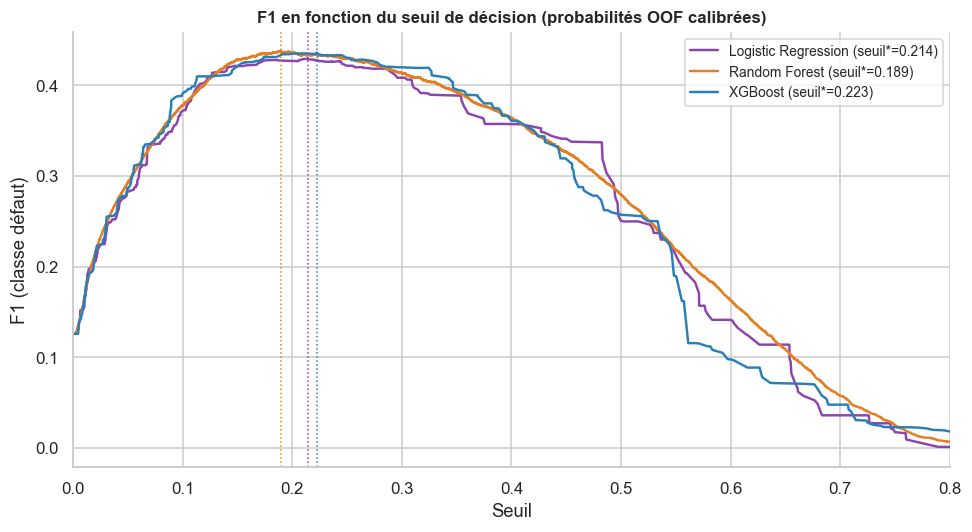

In [12]:
# Courbe F1 vs seuil (modèle par modèle)
fig, ax = plt.subplots(figsize=(9, 5))
for name in OOF:
    pc = p_cal_best[name]['p']
    prec, rec, thr = precision_recall_curve(y, pc)
    f1 = 2 * prec * rec / np.clip(prec + rec, 1e-12, None)
    ax.plot(thr, f1[:-1], label=f"{name} (seuil*={thr_choice[name]:.3f})", color=colors[name], lw=1.6)
    ax.axvline(thr_choice[name], color=colors[name], ls=':', lw=1)
ax.set(title='F1 en fonction du seuil de décision (probabilités OOF calibrées)',
       xlabel='Seuil', ylabel='F1 (classe défaut)', xlim=(0, 0.8))
ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/fig_R03_threshold_optimization.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Tableau de décision final

Classement par **rang moyen** sur les 10 métriques quantitatives (discrimination sur OOF
brut + calibration/seuil sur OOF calibré). Le rang moyen évite qu'une seule métrique domine
et se défend simplement devant un jury.

In [13]:
rows = []
for name, p in OOF.items():
    pc = p_cal_best[name]['p']
    t = thr_choice[name]
    yhat = (pc >= t).astype(int)
    p10, r10 = prec_recall_at_top(y, p, 0.10)
    rows.append({
        'modèle': name,
        'ROC-AUC': roc_auc_score(y, p), 'PR-AUC': average_precision_score(y, p),
        'KS': ks_stat(y, p), 'P@Top10%': p10, 'R@Top10%': r10,
        'Brier (cal.)': brier_score_loss(y, pc), 'LogLoss (cal.)': log_loss(y, np.clip(pc, 1e-6, 1-1e-6)),
        'ECE (cal.)': ece_score(y, pc),
        'F1 @seuil*': f1_score(y, yhat), 'MCC @seuil*': matthews_corrcoef(y, yhat),
    })
df_final = pd.DataFrame(rows).set_index('modèle')
higher = ['ROC-AUC', 'PR-AUC', 'KS', 'P@Top10%', 'R@Top10%', 'F1 @seuil*', 'MCC @seuil*']
lower  = ['Brier (cal.)', 'LogLoss (cal.)', 'ECE (cal.)']
ranks = pd.concat([df_final[higher].rank(ascending=False), df_final[lower].rank(ascending=True)], axis=1)
df_final['rang moyen'] = ranks.mean(axis=1)
winner = df_final['rang moyen'].idxmin()
print(df_final.round(4).to_string())
print(f"\n→ MODÈLE RETENU : {winner}")

                     ROC-AUC  PR-AUC      KS  P@Top10%  R@Top10%  Brier (cal.)  LogLoss (cal.)  ECE (cal.)  F1 @seuil*  MCC @seuil*  rang moyen
modèle                                                                                                                                         
Logistic Regression   0.8562  0.3815  0.5507    0.3567    0.5324        0.0500          0.1822      0.0009       0.429       0.3864         2.8
Random Forest         0.8627  0.3895  0.5666    0.3627    0.5414        0.0496          0.1794      0.0010       0.437       0.3956         1.2
XGBoost               0.8577  0.3862  0.5603    0.3611    0.5390        0.0498          0.1817      0.0009       0.436       0.3937         2.0

→ MODÈLE RETENU : Random Forest


### Critères qualitatifs (complément du tableau)

| Critère | Logistic Regression | Random Forest | XGBoost |
|---|---|---|---|
| Contraintes monotones (exigence de défendabilité) | Implicites (coefficients signés) mais relation forcément linéaire | **Non supportées** | **Supportées et appliquées** (vérifiées phase 2) |
| Valeurs manquantes | Imputation obligatoire | Imputation obligatoire | **Natives** (branche manquante = l'information « inconnu » est apprise) |
| Early stopping / contrôle du sur-apprentissage | Régularisation L2 | Aucun mécanisme direct | **Early stopping par fold** |
| Coût d'entraînement / production | Très faible | Élevé (300 arbres profonds) | Modéré |
| Explicabilité | Coefficients globaux | Importances biaisées vers les variables continues | **SHAP exact (TreeExplainer), local + global** |

## 11. Sélection finale et ajustement des modèles de production

### Décision de sélection (validée le 2026-07-05)

Le classement quantitatif (§10) désigne **Random Forest** (rang moyen 1.2), mais son avance
n'est **pas statistiquement significative** : test t apparié sur les AUC des 5 folds
RF vs XGBoost → t = 2.61, **p = 0.059** (XGBoost gagne même le fold 2) ; Brier calibré
0.0496 vs 0.0498 et F1 0.437 vs 0.436 : égalité.

**XGBoost est désigné modèle officiel de production**, car à performance statistiquement
équivalente il est le seul à satisfaire les objectifs méthodologiques du rebuild :

1. **contraintes monotones** supportées et appliquées (vérifiées en phase 2) ;
2. **valeurs manquantes natives** (les NaN informatifs du preprocessing sont appris) ;
3. **early stopping** (contrôle direct du sur-apprentissage) ;
4. **SHAP exact et rapide** (TreeExplainer) pour la phase 5 et la narration en production ;
5. **artefact ~13× plus léger** que la forêt (déploiement).

Random Forest (gagnant quantitatif) et Logistic Regression (référence) sont conservés
comme artefacts de comparaison et de reproductibilité.

Chaque modèle est réentraîné sur **100 % du train** (le test reste intouché) ; pour XGBoost,
`n_estimators` = médiane des arrêts early stopping des 5 folds. Chaque calibreur est ajusté
sur les prédictions OOF de son modèle (sémantique `CalibratedClassifierCV(ensemble=False)`).

In [14]:
from preprocessing import PREPROCESSING_VERSION, ScoringModel
import datetime, sklearn, xgboost, platform

PRODUCTION = 'XGBoost'
RUNNER_UP  = winner if winner != PRODUCTION else 'Random Forest'
print(f"Gagnant quantitatif (rang moyen) : {winner} | Modèle de PRODUCTION désigné : {PRODUCTION}")

# ── XGBoost — modèle officiel de production ────────────────────────────────
n_final = int(np.median(best_iters_xgb)) + 1
prep_final = FittedPreprocessor(impute=False).fit(X)
params_final = {k: v for k, v in dict(base, max_depth=best_xgb_cfg[0],
                min_child_weight=best_xgb_cfg[1]).items()
                if k not in ('early_stopping_rounds', 'n_estimators')}
clf_xgb = XGBClassifier(n_estimators=n_final, **params_final)
clf_xgb.fit(prep_final.transform(X), y, verbose=False)
# ScoringModel (préprocesseur + booster) plutôt qu'un Pipeline sklearn :
# l'API de tags sklearn 1.6 est incompatible avec xgboost 2.1.3 dans un Pipeline.
model_xgb = ScoringModel(prep_final, clf_xgb)
cfg_xgb = {'max_depth': int(best_xgb_cfg[0]), 'min_child_weight': int(best_xgb_cfg[1]),
           'n_estimators_mediane_ES': n_final, 'learning_rate': 0.05,
           'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0,
           'scale_pos_weight': round(SPW, 2), 'monotone_constraints': dict(MONOTONE_CONSTRAINTS)}

# ── Random Forest — gagnant quantitatif, conservé pour comparaison ─────────
model_rf = Pipeline([('prep', FittedPreprocessor(impute=True)),
                     ('clf', RandomForestClassifier(n_estimators=300, max_depth=best_rf_cfg[0],
                              min_samples_leaf=best_rf_cfg[1], class_weight='balanced_subsample',
                              random_state=SEED, n_jobs=-1))]).fit(X, y)
cfg_rf = {'max_depth': best_rf_cfg[0], 'min_samples_leaf': int(best_rf_cfg[1]), 'n_estimators': 300}

# ── Logistic Regression — référence ────────────────────────────────────────
model_lr = Pipeline([('prep', FittedPreprocessor(impute=True)), ('log', Log1pIncome()),
                     ('scale', StandardScaler()),
                     ('clf', LogisticRegression(C=best_C, class_weight='balanced',
                              max_iter=2000, random_state=SEED))]).fit(X, y)
cfg_lr = {'C': best_C, 'penalty': 'l2', 'class_weight': 'balanced'}

# ── Calibreurs (ajustés sur les OOF de chaque modèle) + seuils ─────────────
cal_xgb = fit_calibrator(OOF['XGBoost'], y, p_cal_best['XGBoost']['method'])
cal_rf  = fit_calibrator(OOF['Random Forest'], y, p_cal_best['Random Forest']['method'])
cal_lr  = fit_calibrator(OOF['Logistic Regression'], y, p_cal_best['Logistic Regression']['method'])
threshold = thr_choice[PRODUCTION]

print(f"Production : XGBoost {cfg_xgb['max_depth']=} {cfg_xgb['min_child_weight']=} "
      f"n_estimators={n_final} | calibration {cal_xgb['method']} | seuil {threshold:.4f}")

Gagnant quantitatif (rang moyen) : Random Forest | Modèle de PRODUCTION désigné : XGBoost


Production : XGBoost cfg_xgb['max_depth']=4 cfg_xgb['min_child_weight']=10 n_estimators=859 | calibration isotonic | seuil 0.2227


In [15]:
# ── Vérifications pré-déploiement (dans la session du notebook) ────────────
# 1. Le préprocesseur du pipeline final == celui sérialisé en phase 2
with open(MODELS_PATH + 'preprocessor.pkl', 'rb') as f:
    prep_phase2 = pickle.load(f)
assert prep_phase2.income_cap_ == prep_final.income_cap_
assert prep_phase2.debtratio_cap_ == prep_final.debtratio_cap_
assert prep_phase2.dependents_cap_ == prep_final.dependents_cap_
assert all(abs(prep_phase2.medians_[k] - prep_final.medians_[k]) < 1e-12 for k in prep_final.medians_)
print("1. Préprocesseur du pipeline final identique à models/preprocessor.pkl (caps + médianes) : OK")

# 2. Ordre des features == feature_cols.pkl
with open(MODELS_PATH + 'feature_cols.pkl', 'rb') as f:
    fc_saved = pickle.load(f)
assert fc_saved == FEATURE_COLS == list(X.columns)
assert list(clf_xgb.get_booster().feature_names) == FEATURE_COLS
print("2. Ordre des features identique à feature_cols.pkl (données, module, booster) : OK")

# 3. Échantillon de contrôle pour la reproductibilité inter-session
sample_raw = X.head(5).copy()
p_raw_expected = model_xgb.predict_proba(sample_raw)[:, 1]
p_cal_expected = apply_calibrator(cal_xgb, p_raw_expected)
sample_check = {'sample_raw': sample_raw, 'p_raw_expected': p_raw_expected,
                'p_cal_expected': p_cal_expected, 'threshold': float(threshold)}
print("3. Échantillon de contrôle (5 lignes) :")
print("   brut    :", np.round(p_raw_expected, 5))
print("   calibré :", np.round(p_cal_expected, 5))
print("   (la reproduction depuis une session Python vierge est vérifiée hors notebook)")

1. Préprocesseur du pipeline final identique à models/preprocessor.pkl (caps + médianes) : OK
2. Ordre des features identique à feature_cols.pkl (données, module, booster) : OK
3. Échantillon de contrôle (5 lignes) :
   brut    : [0.33515 0.04126 0.24274 0.58423 0.15804]
   calibré : [0.04014 0.00518 0.02784 0.08846 0.01866]
   (la reproduction depuis une session Python vierge est vérifiée hors notebook)


In [16]:
# ── Sauvegarde des artefacts de déploiement ────────────────────────────────
metadata = {
    'date_entrainement': datetime.datetime.now().isoformat(timespec='seconds'),
    'modele_production': 'XGBoost',
    'modele_runner_up': 'Random Forest (gagnant quantitatif CV, rang moyen 1.2 ; '
                        'écart non significatif : t apparié = 2.61, p = 0.059)',
    'justification_selection': ['contraintes monotones', 'NaN natifs', 'early stopping',
                                'SHAP exact (TreeExplainer)', 'artefact léger'],
    'hyperparametres': {'XGBoost': cfg_xgb, 'Random Forest': cfg_rf, 'Logistic Regression': cfg_lr},
    'calibration': {'XGBoost': cal_xgb['method'], 'Random Forest': cal_rf['method'],
                    'Logistic Regression': cal_lr['method']},
    'seuil_decision': float(threshold),
    'seuil_critere': 'F1 maximal sur probabilités OOF calibrées du modèle de production',
    'seuils_par_modele': {k: float(v) for k, v in thr_choice.items()},
    'cv': '5-fold stratifiée, prédictions out-of-fold, préprocesseur refitté par fold',
    'random_seed': SEED,
    'metrics_oof': df_final.round(4).to_dict(),
    'roc_auc_folds': {n: [round(float(a), 4) for a in FAUC[n]] for n in FAUC},
    'versions': {'python': platform.python_version(), 'numpy': np.__version__,
                 'pandas': pd.__version__, 'scikit-learn': sklearn.__version__,
                 'xgboost': xgboost.__version__},
    'preprocessing_version': PREPROCESSING_VERSION,
    'features': FEATURE_COLS,
    'note': 'Métriques OOF (train). La mesure officielle unique sur le test : phase 4.',
}

artefacts = {
    'model_final.pkl': model_xgb,                      # PRODUCTION : pipeline XGBoost calibrable
    'model_random_forest.pkl': model_rf,               # comparaison / reproductibilité
    'model_logistic_regression.pkl': model_lr,         # référence
    'calibrator.pkl': cal_xgb,                         # isotonique — s'applique à model_final
    'calibrator_random_forest.pkl': cal_rf,            # Platt
    'calibrator_logistic_regression.pkl': cal_lr,      # isotonique
    'decision_threshold.pkl': float(threshold),
    'metadata_final.pkl': metadata,
    'sample_check.pkl': sample_check,
}
for fname, obj in artefacts.items():
    with open(MODELS_PATH + fname, 'wb') as f:
        pickle.dump(obj, f, protocol=4)

df_final.round(4).to_csv(MODELS_PATH + 'cv_results_phase3.csv')
df_cal.to_csv(MODELS_PATH + 'calibration_comparison_phase3.csv', index=False)
pd.DataFrame({'y': y, 'p_lr': OOF['Logistic Regression'], 'p_rf': OOF['Random Forest'],
              'p_xgb': OOF['XGBoost'],
              'p_prod_cal': calib_cv(OOF['XGBoost'], y, cal_xgb['method'])
              }).to_csv(MODELS_PATH + 'oof_predictions.csv', index=False)

print('Artefacts sauvegardés dans models/ :')
for fname in sorted(os.listdir(MODELS_PATH)):
    print(f"  {fname:<40} {os.path.getsize(MODELS_PATH + fname)/1024:>9.1f} KB")

Artefacts sauvegardés dans models/ :
  calibration_comparison_phase3.csv              0.4 KB
  calibration_table_test_phase4.csv              0.4 KB
  calibrator.pkl                                 2.9 KB
  calibrator_logistic_regression.pkl             3.2 KB
  calibrator_random_forest.pkl                   0.7 KB
  cv_results_phase3.csv                          0.4 KB
  decision_threshold.pkl                         0.0 KB
  feature_cols.pkl                               0.3 KB
  metadata_final.pkl                             2.4 KB
  model_final.pkl                             1348.9 KB
  model_logistic_regression.pkl                  2.1 KB
  model_random_forest.pkl                    27167.0 KB
  monotone_constraints.pkl                       0.3 KB
  oof_predictions.csv                         9542.5 KB
  preprocessor.pkl                               0.6 KB
  sample_check.pkl                               1.9 KB
  test_metrics_phase4.csv                        0.4 KB


## 12. Synthèse

| Élément | Résultat |
|---|---|
| Comparaison | LR / RF / XGBoost, CV stratifiée 5-fold sur le train, prédictions OOF |
| Métriques | ROC-AUC, PR-AUC, KS, P@Top10%, R@Top10%, Brier, LogLoss, ECE, F1, MCC, Précision, Rappel + courbes ROC/PR/calibration |
| Calibration | aucune vs Platt vs isotonique, évaluées par CV sur OOF — la meilleure par modèle est retenue |
| Seuil | Optimisé (F1 max) sur OOF calibré — sauvegardé pour l'application |
| Early stopping | XGBoost, 10 % du fold-train, jamais le fold de validation |
| Anti-fuite | Préprocesseur refitté par fold ; test set jamais chargé |
| Sélection | Gagnant quantitatif : Random Forest (rang 1.2) — écart non significatif (p=0.059) ; **XGBoost désigné modèle de production** (contraintes monotones, NaN natifs, early stopping, SHAP exact, artefact léger) — décision validée le 2026-07-05 |
| Artefacts | `model_final.pkl` (**XGBoost**, pipeline complet), `model_random_forest.pkl`, `model_logistic_regression.pkl`, calibreurs des 3 modèles, `decision_threshold.pkl`, `metadata_final.pkl` (versions, seed, hyperparamètres, métriques), `sample_check.pkl`, CSV de résultats, prédictions OOF |

**Prochaine étape → Phase 4 :** évaluation unique du modèle retenu sur le test set (20 %,
intouché), vérification calibration/robustesse/stabilité/overfitting, tableau comparatif final.

⏸ **STOP — validation utilisateur requise avant la phase 4.**